In [1]:
import openml
import pandas as pd
import numpy as np
import os
# Grid search over k-center matching hyperparameters + OCT training
# Find best configuration based on PR-AUC
import kcenter_hyperparameter_search_global
import importlib
importlib.reload(kcenter_hyperparameter_search_global)
from kcenter_hyperparameter_search_global import run_global_kcenter_matching, build_undersampled_dataset
import model_IAI
importlib.reload(model_IAI)
from model_IAI import finetune_oct, evaluate_binary_oct
from itertools import product
RESULTS_DIR = "./uci_experiments_results"

# Load Kaggle Credit Card Fraud Detection dataset
df_fraud_raw = pd.read_csv("creditcard.csv")
# Separate features and target (target column is 'Class')
X_fraud = df_fraud_raw.drop('Class', axis=1)
y_fraud = df_fraud_raw['Class']

In [2]:
# CORRECTED VERSION: Prepare datasets for k-center matching
# Replace the function in the cell above with this corrected version

def prepare_dataset_for_kcenter(X, y, dataset_name):
    """
    Prepare a dataset for k-center matching by:
    1. Creating ENROLID column
    2. Converting target from -1/1 to 0/1 (1 = minority/cases, 0 = majority/controls)
    3. Combining features and target into a single dataframe
    
    This version handles object types and different target formats.
    """
    # Create dataframe with features
    df = X.copy()
    
    # Add ENROLID (using index + 1 as IDs)
    df['ENROLID'] = range(1, len(df) + 1)
    
    # Convert target to numeric if it's not already
    y_numeric = pd.to_numeric(y, errors='coerce')
    
    # Check unique values to determine format
    unique_vals = y_numeric.dropna().unique()
    
    # Convert target based on format:
    # - If values are -1 and 1: convert -1 -> 0, 1 -> 1
    # - If values are already 0 and 1: keep as is
    if set(unique_vals).issubset({-1, 1}):
        # Format is -1/1, convert -1 -> 0, 1 -> 1
        df['target'] = ((y_numeric == 1).astype(int))
    elif set(unique_vals).issubset({0, 1}):
        # Format is already 0/1
        df['target'] = y_numeric.astype(int)
    else:
        # Find the minority class (smaller count) and map it to 1
        value_counts = y_numeric.value_counts()
        minority_value = value_counts.idxmin()
        df['target'] = (y_numeric == minority_value).astype(int)
        print(f"  Note: Mapped minority class value {minority_value} to 1")
    
    # Reorder columns to put ENROLID and target first
    cols = ['ENROLID', 'target'] + [c for c in df.columns if c not in ['ENROLID', 'target']]
    df = df[cols]
    
    print(f"\n=== {dataset_name.upper()} DATASET PREPARED ===")
    print(f"Shape: {df.shape}")
    print(f"Original target type: {type(y)}")
    print(f"Original target unique values: {sorted(unique_vals)}")
    print(f"Target distribution:")
    print(df['target'].value_counts().sort_index())
    print(f"Class imbalance ratio: {df['target'].value_counts().min() / df['target'].value_counts().max():.4f}")
    
    return df



In [3]:
# Explore credit card fraud dataset
if X_fraud is not None:
    print("=== CREDIT CARD FRAUD DATASET ===")
    print(f"Shape: {X_fraud.shape}")
    print(f"\nFeatures ({len(X_fraud.columns)}):")
    print(X_fraud.columns.tolist())
    print(f"\nFeature types:")
    print(X_fraud.dtypes.value_counts())
    print(f"\nTarget variable: 'Class'")
    print(f"Target distribution:\n{y_fraud.value_counts()}")
    print(f"\nClass imbalance ratio: {y_fraud.value_counts().min() / y_fraud.value_counts().max():.4f}")
    print(f"\nFirst few rows:")
    X_fraud.head()
    
    # Show some statistics
    print(f"\nDataset statistics:")
    print(f"  Total samples: {len(X_fraud):,}")
    print(f"  Fraud cases (1): {y_fraud.sum():,} ({y_fraud.mean()*100:.2f}%)")
    print(f"  Normal cases (0): {(y_fraud == 0).sum():,} ({(1-y_fraud.mean())*100:.2f}%)")
else:
    print("⚠️  Credit card fraud dataset not loaded. Please download from Kaggle first.")

=== CREDIT CARD FRAUD DATASET ===
Shape: (284807, 30)

Features (30):
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']

Feature types:
float64    30
Name: count, dtype: int64

Target variable: 'Class'
Target distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Class imbalance ratio: 0.0017

First few rows:

Dataset statistics:
  Total samples: 284,807
  Fraud cases (1): 492 (0.17%)
  Normal cases (0): 284,315 (99.83%)


In [4]:
def setup_feature_columns(df, target_col='target', drop_time=True, log1p_amount=True):
    """
    Setup feature columns, categorical columns, and numeric columns.
    Optionally:
      - drop Time from features
      - replace Amount with Amount_log = log1p(Amount)
    Returns: df_out, feature_cols, cat_cols, true_num_cols, bin_cols
    """
    df_out = df.copy()

    # --- Amount log transform (create new column; drop raw Amount from features) ---
    if log1p_amount and "Amount" in df_out.columns:
        # Guard: Amount should be nonnegative in this dataset; clip just in case
        amt = pd.to_numeric(df_out["Amount"], errors="coerce").fillna(0.0)
        amt = np.clip(amt, a_min=0.0, a_max=None)
        df_out["Amount_log"] = np.log1p(amt)
    else:
        df_out["Amount_log"] = np.nan  # not used, but keeps downstream code robust

    # --- Feature columns ---
    exclude = {"ENROLID", target_col}
    if drop_time:
        exclude.add("Time")

    # If we created Amount_log, exclude raw Amount and use Amount_log instead
    if log1p_amount and "Amount" in df_out.columns:
        exclude.add("Amount")

    feature_cols = [c for c in df_out.columns if c not in exclude]

    # Ensure Amount_log is included (and is numeric)
    if log1p_amount and "Amount_log" in df_out.columns and "Amount_log" not in feature_cols:
        feature_cols.append("Amount_log")

    # --- Column type discovery (on feature_cols) ---
    cat_cols = df_out[feature_cols].select_dtypes(include=["object", "category"]).columns.tolist()
    numeric_cols = df_out[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

    # Binary detection
    bin_cols = []
    for col in numeric_cols:
        u = df_out[col].dropna().unique()
        if len(u) <= 2 and set(u).issubset({0, 1, 0.0, 1.0}):
            bin_cols.append(col)

    true_num_cols = [c for c in numeric_cols if c not in bin_cols]

    print(f"\n=== COLUMN SETUP ===")
    print(f"Total features: {len(feature_cols)}")
    print(f"Categorical columns: {len(cat_cols)}")
    print(f"Binary columns: {len(bin_cols)}")
    print(f"True numeric columns: {len(true_num_cols)}")
    if log1p_amount and "Amount" in df_out.columns:
        print("Using Amount_log = log1p(Amount) and excluding raw Amount.")
    if drop_time and "Time" in df_out.columns:
        print("Dropping Time from features.")

    return df_out, feature_cols, cat_cols, true_num_cols, bin_cols


# Train/test splits (similar to kcenter_hyperparameter_search_global.py)
from sklearn.model_selection import train_test_split

TRAIN_TEST_SEED = 123

def create_train_test_split(df, target_col='target', test_size=0.3, val_size=0.5, random_state=123):
    """
    Create train/val/test splits similar to the main script.
    Returns: train_df, val_df, test_df
    """
    # First split: train vs (val+test)
    train_df, temp_df = train_test_split(
        df, 
        test_size=test_size, 
        stratify=df[target_col], 
        random_state=random_state
    )
    
    # Second split: val vs test (from temp_df)
    val_df, test_df = train_test_split(
        temp_df,
        test_size=val_size,
        stratify=temp_df[target_col],
        random_state=random_state
    )
    
    print(f"\n=== DATA SPLITS ===")
    print(f"Train: {len(train_df):,} samples")
    print(f"  - Minority: {(train_df[target_col] == 1).sum():,}")
    print(f"  - Majority: {(train_df[target_col] == 0).sum():,}")
    print(f"Val: {len(val_df):,} samples")
    print(f"  - Minority: {(val_df[target_col] == 1).sum():,}")
    print(f"  - Majority: {(val_df[target_col] == 0).sum():,}")
    print(f"Test: {len(test_df):,} samples")
    print(f"  - Minority: {(test_df[target_col] == 1).sum():,}")
    print(f"  - Majority: {(test_df[target_col] == 0).sum():,}")
    
    return train_df, val_df, test_df




In [5]:
# Setup for credit card fraud dataset
if X_fraud is not None:
    df_fraud = prepare_dataset_for_kcenter(X_fraud, y_fraud, "credit_card_fraud")
    df_fraud,feature_cols_fraud, CAT_COLUMNS_FRAUD, TRUE_NUM_COLUMNS_FRAUD, BIN_COLUMNS_FRAUD = setup_feature_columns(df_fraud)
    train_fraud, val_fraud, test_fraud = create_train_test_split(df_fraud, random_state=TRAIN_TEST_SEED)
    display(train_fraud.columns)
else:
    print("\n⚠️  Skipping credit card fraud dataset splits (file not loaded)")


=== CREDIT_CARD_FRAUD DATASET PREPARED ===
Shape: (284807, 32)
Original target type: <class 'pandas.core.series.Series'>
Original target unique values: [np.int64(0), np.int64(1)]
Target distribution:
target
0    284315
1       492
Name: count, dtype: int64
Class imbalance ratio: 0.0017

=== COLUMN SETUP ===
Total features: 29
Categorical columns: 0
Binary columns: 0
True numeric columns: 29
Using Amount_log = log1p(Amount) and excluding raw Amount.
Dropping Time from features.

=== DATA SPLITS ===
Train: 199,364 samples
  - Minority: 344
  - Majority: 199,020
Val: 42,721 samples
  - Minority: 74
  - Majority: 42,647
Test: 42,722 samples
  - Minority: 74
  - Majority: 42,648


Index(['ENROLID', 'target', 'Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7',
       'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17',
       'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27',
       'V28', 'Amount', 'Amount_log'],
      dtype='object')

In [ ]:
# Precompute case-control distances (required for k-center matching)
# This follows the pattern from kcenter_hyperparameter_search_global.py

from precompute_distances import compute_distances_batched, save_distances_hdf5
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

def get_preprocessor_with_impute(categorical_cols, numeric_cols, verbose=True):
    if verbose:
        print("→ Building preprocessor w/ imputation:")
        print(f"   • Cat: impute(most_frequent) + OHE on: {categorical_cols}")
        print(f"   • Num: impute(median) + scale on: {numeric_cols}")
    assert "Amount_log" in feature_cols_fraud, "Amount_log missing from feature_cols"
    assert "Amount" not in feature_cols_fraud, "Raw Amount is still in feature_cols"
    assert "Time" not in feature_cols_fraud, "Time should be dropped for distance space"

    transformers = []

    if categorical_cols:
        cat_pipe = Pipeline(steps=[
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(drop="first", handle_unknown="ignore")),
        ])
        transformers.append(("cat", cat_pipe, categorical_cols))

    if numeric_cols:
        num_pipe = Pipeline(steps=[
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ])
        transformers.append(("num", num_pipe, numeric_cols))
    
    return ColumnTransformer(transformers=transformers, remainder="drop")


def precompute_case_control_distances(
    train_df, target_col, feature_cols,
    cat_columns, true_num_columns,
    dataset_name, seed=123
):
    covered = set([c for c in cat_columns if c in feature_cols] + [c for c in true_num_columns if c in feature_cols])
    dropped = [c for c in feature_cols if c not in covered]
    assert len(dropped) == 0, f"These feature_cols are being dropped by preprocessor: {dropped}"

    cases = train_df[train_df[target_col] == 1].copy()
    controls = train_df[train_df[target_col] == 0].copy()

    X_cases = cases[feature_cols].copy()
    X_controls = controls[feature_cols].copy()

    print(f"Cases (minority): {len(cases):,}")
    print(f"Controls (majority): {len(controls):,}")

    # Fit preprocessing on controls only
    preprocessor = get_preprocessor_with_impute(
        categorical_cols=[c for c in cat_columns if c in X_controls.columns],
        numeric_cols=[c for c in true_num_columns if c in X_controls.columns],
        verbose=True
    )
    X_controls_processed = preprocessor.fit_transform(X_controls)
    X_cases_processed = preprocessor.transform(X_cases)

    # (Optional) sanity checks
    import numpy as np
    assert np.isfinite(X_controls_processed).all()
    assert np.isfinite(X_cases_processed).all()

    distances = compute_distances_batched(
        X_controls_processed, X_cases_processed,
        batch_size=1000, dtype=np.float32
    )
    print(f"  Distance matrix shape: {distances.shape}")
    print(f"  Distance range: [{distances.min():.3f}, {distances.max():.3f}]")
    print(f"  Distance mean: {distances.mean():.3f}")
    
    # Save to H5
    output_dir = "./precomputed_distances"
    os.makedirs(output_dir, exist_ok=True)
    h5_path = os.path.join(output_dir, f"distances_{dataset_name}_seed_{seed}_new.h5")
    
    majority_enrolids = controls["ENROLID"].to_numpy()
    minority_enrolids = cases["ENROLID"].to_numpy()
    
    save_distances_hdf5(
        distances,
        majority_enrolids,
        minority_enrolids,
        h5_path,
        compression='gzip'
    )
    
    print(f"\n✓ Saved distances to: {h5_path}")
    
    return h5_path, X_controls_processed, majority_enrolids



In [11]:
# Precompute distances for credit card fraud dataset
h5_path_fraud, X_controls_fraud, majority_enrolids_fraud = precompute_case_control_distances(
    train_fraud, 'target', feature_cols_fraud, CAT_COLUMNS_FRAUD, TRUE_NUM_COLUMNS_FRAUD,
    'creditcard_fraud', seed=TRAIN_TEST_SEED
)

Cases (minority): 344
Controls (majority): 199,020
→ Building preprocessor w/ imputation:
   • Cat: impute(most_frequent) + OHE on: []
   • Num: impute(median) + scale on: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_log']
Computing 199,020 x 344 = 68,462,880 distances
Output size: 273.9 MB (<class 'numpy.float32'>)


Computing distances: 100%|██████████| 200/200 [00:00<00:00, 1018.02it/s]


  Distance matrix shape: (199020, 344)
  Distance range: [0.085, 217.905]
  Distance mean: 24.063

Saving to HDF5: ./precomputed_distances/distances_creditcard_fraud_seed_123_new.h5
  ✓ Saved 241.0 MB

✓ Saved distances to: ./precomputed_distances/distances_creditcard_fraud_seed_123_new.h5


## OCT gridsearch for best kcenter config

AUC score: 0.904
PR-AUC (Average Precision): 0.608
Best MCC: 0.757 @ threshold=0.454579
Balanced (G-mean) recall: 0.689
Balanced (G-mean) specificity: 0.999
Number of leaves: 4

VS. BALANCED

AUC score: 0.911
PR-AUC (Average Precision): 0.494
Best MCC: 0.693 @ threshold=0.548562
Balanced (G-mean) recall: 0.824
Balanced (G-mean) specificity: 0.990
Number of leaves: 3

MATCHING RATIO COMPARISON: K-CENTER MATCHING + OCT TRAINING

Fixed hyperparameters:
  seed_method: random
  case_weighting: None
  use_adaptive_pool: True

Matching ratios to test: [1, 2, 3, 4, 5]

CREDIT CARD FRAUD DATASET - MATCHING RATIO COMPARISON

################################################################################
MATCHING RATIO: 1:1
################################################################################

GLOBAL K-CENTER MATCHING CONFIGURATION:
  case_weighting: None
  use_adaptive_pool: True
  seed_method: random
  matching_ratio: 1:1

Global Statistics:
  Cases (minority): 344
  Controls (majority): 199,020
  Ratio: 578.55:1

  Preprocessing:
    Features: 31
    Preprocessed shape: (199020, 31)

  Preparing control-control distances (global)...
    ✓ Found existing global d_nn files with matching ENROLIDs:
      d_nn matrix: ./precomputed_distances/global_dnn_fraud_seed_123/leaf_global_dnn_matrix.npy
      d_nn enrolids: ./precomputed_distances/global_dnn_

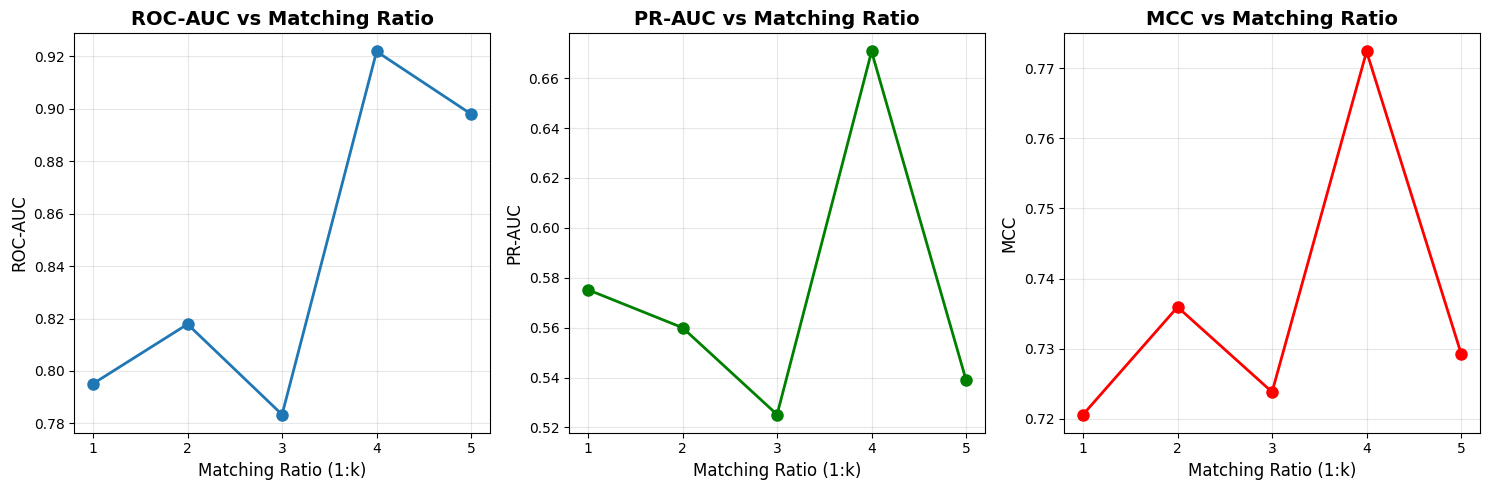


COMPARISON COMPLETE


In [30]:
h5_path_fraud = os.path.join(f"./precomputed_distances/distances_creditcard_fraud_seed_{TRAIN_TEST_SEED}_new.h5")

# OCT hyperparameters
OCT_DEPTHS = [7, 9]
OCT_MINBUCKETS_FRAUD = [25,50,100]
OCT_CPS = [0.00001, 0.0001, 0.001, 0.01]

# Results directory
RESULTS_DIR = "./uci_experiments_results/matching_ratio_comparison"
os.makedirs(RESULTS_DIR, exist_ok=True)

# Fixed hyperparameters for k-center matching
SEED_METHOD = "random"
CASE_WEIGHTING = None
USE_ADAPTIVE_POOL = True

# Matching ratios to test
MATCHING_RATIOS = [1, 2, 3, 4, 5]

print("="*80)
print("MATCHING RATIO COMPARISON: K-CENTER MATCHING + OCT TRAINING")
print("="*80)
print(f"\nFixed hyperparameters:")
print(f"  seed_method: {SEED_METHOD}")
print(f"  case_weighting: {CASE_WEIGHTING}")
print(f"  use_adaptive_pool: {USE_ADAPTIVE_POOL}")
print(f"\nMatching ratios to test: {MATCHING_RATIOS}")

# Import matplotlib for plotting
import matplotlib.pyplot as plt

# ============================================================================
# CREDIT CARD FRAUD DATASET
# ============================================================================
if 'X_fraud' in globals() and X_fraud is not None:
    print("\n" + "="*80)
    print("CREDIT CARD FRAUD DATASET - MATCHING RATIO COMPARISON")
    print("="*80)
    
    # Prepare validation and test sets
    X_val_fraud = val_fraud[feature_cols_fraud]
    y_val_fraud = val_fraud['target']
    X_test_fraud = test_fraud[feature_cols_fraud]
    y_test_fraud = test_fraud['target']
    
    # Use dataset-specific DNN directory to avoid conflicts
    dnn_dir_fraud = f"./precomputed_distances/global_dnn_fraud_seed_{TRAIN_TEST_SEED}"
    
    # Store all results
    all_results_fraud = []
    
    # Loop over matching ratios
    for matching_ratio in MATCHING_RATIOS:
        print(f"\n{'#'*80}")
        print(f"MATCHING RATIO: 1:{matching_ratio}")
        print(f"{'#'*80}")
        
        config_name = f"seed_{SEED_METHOD}_cw_{CASE_WEIGHTING}_pool_{USE_ADAPTIVE_POOL}_ratio_{matching_ratio}"
        
        # Run k-center matching
        matching_result = run_global_kcenter_matching(
            train_pd=train_fraud,
            target_col='target',
            feature_cols=feature_cols_fraud,
            pn_h5_path=h5_path_fraud,
            matching_ratio=matching_ratio,
            case_weighting=CASE_WEIGHTING,
            use_adaptive_pool=USE_ADAPTIVE_POOL,
            seed_method=SEED_METHOD,
            CAT_COLUMNS=CAT_COLUMNS_FRAUD,
            TRUE_NUM_COLUMNS=TRUE_NUM_COLUMNS_FRAUD,
            COST_COLUMNS=None,
            dnn_out_dir=dnn_dir_fraud,
        )
        
        # Build undersampled dataset
        undersampled_fraud = build_undersampled_dataset(
            train_pd=train_fraud,
            matching_result=matching_result,
            target_col='target',
            matching_ratio=matching_ratio,
        )
        
        # Train OCT
        print(f"\nTraining OCT for ratio 1:{matching_ratio}...")
        balanced_model, balanced_params, _, preprocessor, feature_names = finetune_oct(
            X_train=undersampled_fraud[feature_cols_fraud],
            y_train=undersampled_fraud['target'],
            X_val=X_val_fraud,
            y_val=y_val_fraud,
            categorical_cols=CAT_COLUMNS_FRAUD,
            numeric_cols=TRUE_NUM_COLUMNS_FRAUD,
            depths=OCT_DEPTHS,
            minbuckets=OCT_MINBUCKETS_FRAUD,
            cps=OCT_CPS,
        )
        
        # Evaluate on TEST set (final evaluation)
        test_metrics = evaluate_binary_oct(
            balanced_model, X_test_fraud, y_test_fraud,
            preprocessor, feature_names,
            results_dir=RESULTS_DIR, save_suffix=f"fraud_ratio_{matching_ratio}",
            X_val_df=X_val_fraud, y_val=y_val_fraud  # Use validation for threshold tuning
        )
        
        # Extract metrics
        test_auc = test_metrics.get('auc', 0) if isinstance(test_metrics.get('auc'), (int, float)) else 0
        test_pr_auc = test_metrics.get('pr_auc', 0) if isinstance(test_metrics.get('pr_auc'), (int, float)) else 0
        test_mcc = test_metrics.get('best_mcc', 0) if isinstance(test_metrics.get('best_mcc'), (int, float)) else 0
        
        # Store results
        result = {
            'matching_ratio': matching_ratio,
            'config_name': config_name,
            'seed_method': SEED_METHOD,
            'case_weighting': CASE_WEIGHTING,
            'use_adaptive_pool': USE_ADAPTIVE_POOL,
            'n_train_samples': len(undersampled_fraud),
            'n_train_minority': (undersampled_fraud['target'] == 1).sum(),
            'n_train_majority': (undersampled_fraud['target'] == 0).sum(),
            'test_auc': test_auc,
            'test_pr_auc': test_pr_auc,
            'test_mcc': test_mcc,
        }
        all_results_fraud.append(result)
        
        print(f"\n✓ Ratio 1:{matching_ratio} complete")
        print(f"   Test AUC: {test_auc:.4f}")
        print(f"   Test PR-AUC: {test_pr_auc:.4f}")
        print(f"   Test MCC: {test_mcc:.4f}")
        print(f"   Training samples: {len(undersampled_fraud):,} (minority: {(undersampled_fraud['target'] == 1).sum():,}, majority: {(undersampled_fraud['target'] == 0).sum():,})")

    # Create results dataframe
    if all_results_fraud:
        results_df = pd.DataFrame(all_results_fraud)
        results_df = results_df.sort_values('matching_ratio')
        
        print(f"\n{'='*80}")
        print("RESULTS SUMMARY")
        print(f"{'='*80}\n")
        print(results_df[['matching_ratio', 'test_auc', 'test_pr_auc', 'test_mcc', 'n_train_samples']].to_string(index=False))
        
        # Save results to CSV
        results_df.to_csv(f"{RESULTS_DIR}/matching_ratio_comparison_results.csv", index=False)
        print(f"\n✓ Results saved to: {RESULTS_DIR}/matching_ratio_comparison_results.csv")
        
        # ========================================================================
        # PLOT RESULTS
        # ========================================================================
        print(f"\n{'='*80}")
        print("PLOTTING RESULTS")
        print(f"{'='*80}\n")
        
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        # Plot AUC
        axes[0].plot(results_df['matching_ratio'], results_df['test_auc'], marker='o', linewidth=2, markersize=8)
        axes[0].set_xlabel('Matching Ratio (1:k)', fontsize=12)
        axes[0].set_ylabel('ROC-AUC', fontsize=12)
        axes[0].set_title('ROC-AUC vs Matching Ratio', fontsize=14, fontweight='bold')
        axes[0].grid(True, alpha=0.3)
        axes[0].set_xticks(MATCHING_RATIOS)
        
        # Plot PR-AUC
        axes[1].plot(results_df['matching_ratio'], results_df['test_pr_auc'], marker='o', linewidth=2, markersize=8, color='green')
        axes[1].set_xlabel('Matching Ratio (1:k)', fontsize=12)
        axes[1].set_ylabel('PR-AUC', fontsize=12)
        axes[1].set_title('PR-AUC vs Matching Ratio', fontsize=14, fontweight='bold')
        axes[1].grid(True, alpha=0.3)
        axes[1].set_xticks(MATCHING_RATIOS)
        
        # Plot MCC
        axes[2].plot(results_df['matching_ratio'], results_df['test_mcc'], marker='o', linewidth=2, markersize=8, color='red')
        axes[2].set_xlabel('Matching Ratio (1:k)', fontsize=12)
        axes[2].set_ylabel('MCC', fontsize=12)
        axes[2].set_title('MCC vs Matching Ratio', fontsize=14, fontweight='bold')
        axes[2].grid(True, alpha=0.3)
        axes[2].set_xticks(MATCHING_RATIOS)
        
        plt.tight_layout()
        
        # Save plot
        plot_path = f"{RESULTS_DIR}/matching_ratio_comparison_plot.png"
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        print(f"✓ Plot saved to: {plot_path}")
        
        plt.show()
        
        print(f"\n{'='*80}")
        print("COMPARISON COMPLETE")
        print(f"{'='*80}")
    else:
        print("\n⚠️  No results to display")

# CREDIT CARD FRAUD DATASET - BASELINE

In [ ]:
# Prepare validation and test sets
X_val_fraud = val_fraud[feature_cols_fraud]
y_val_fraud = val_fraud['target']
X_test_fraud = test_fraud[feature_cols_fraud]
y_test_fraud = test_fraud['target']

# Prepare original imbalanced training set
X_train_fraud_imbalanced = train_fraud[feature_cols_fraud]
y_train_fraud_imbalanced = train_fraud['target']


In [ ]:
import time
try:
    import psutil
    PSUTIL_AVAILABLE = True
except ImportError:
    PSUTIL_AVAILABLE = False
    print("Warning: psutil not available. Resource tracking will be limited.")

def format_time(seconds):
    """Format time in a readable way."""
    if seconds < 0.1:
        return f"{seconds:.4f}"
    elif seconds < 1.0:
        return f"{seconds:.3f}"
    else:
        return f"{seconds:.2f}"

def get_resource_usage():
    """Get current CPU and memory usage."""
    if PSUTIL_AVAILABLE:
        process = psutil.Process()
        memory_info = process.memory_info()
        return {
            'cpu_percent': process.cpu_percent(interval=0.1),
            'memory_mb': memory_info.rss / (1024 * 1024),  # RSS in MB
            'memory_percent': process.memory_percent(),
        }
    else:
        return {
            'cpu_percent': None,
            'memory_mb': None,
            'memory_percent': None,
        }

print(f"\nOriginal training set distribution:")
print(f"  Total samples: {len(X_train_fraud_imbalanced):,}")
print(f"  Minority (1): {y_train_fraud_imbalanced.sum():,} ({y_train_fraud_imbalanced.mean()*100:.2f}%)")
print(f"  Majority (0): {(y_train_fraud_imbalanced == 0).sum():,} ({(1-y_train_fraud_imbalanced.mean())*100:.2f}%)")
print(f"  Imbalance ratio: {(y_train_fraud_imbalanced == 0).sum() / y_train_fraud_imbalanced.sum():.2f}:1")

# Train OCT on imbalanced data
print(f"\n{'='*80}")
print("TRAINING OCT MODEL: Credit Card Fraud Dataset (Imbalanced Baseline)")
print(f"{'='*80}\n")
# Track resources before training
resources_before = get_resource_usage()
training_start_time = time.perf_counter()

baseline_model_fraud, baseline_params_fraud, _, baseline_preprocessor_fraud, baseline_feature_names_fraud = finetune_oct(
    X_train=X_train_fraud_imbalanced,
    y_train=y_train_fraud_imbalanced,
    X_val=X_val_fraud,
    y_val=y_val_fraud,
    categorical_cols=CAT_COLUMNS_FRAUD,
    numeric_cols=TRUE_NUM_COLUMNS_FRAUD,
    depths=[5,7,9],
    minbuckets=[100,150],
    cps=[0.00001,0.0001,0.001,0.01],
)


## best : (5, 100, 1e-05) -- 0.904 AUC, 0.608 PR-AUC, 0.757 MCC
# best over depths 5,7,9: (7, 150, 1e-05) -- 0.876 AUC, PR-AUC 0.576, MCC 0.757
training_end_time = time.perf_counter()
training_time = training_end_time - training_start_time
resources_after_training = get_resource_usage()



Original training set distribution:
  Total samples: 199,364
  Minority (1): 344 (0.17%)
  Majority (0): 199,020 (99.83%)
  Imbalance ratio: 578.55:1

TRAINING OCT MODEL: Credit Card Fraud Dataset (Imbalanced Baseline)

Finetuning OCT with depths: [5, 7, 9], minbuckets: [100, 150], cps: [1e-05, 0.0001, 0.001, 0.01], for best PR-AUC!!!
→ Building preprocessor:
   • OneHotEncoder on: []
   • StandardScaler on: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_log']
Best params: (7, 150, 1e-05) @ PR-AUC: 0.616


In [14]:

# Evaluate
evaluation_start_time = time.perf_counter()
# Evaluate
baseline_metrics_fraud = evaluate_binary_oct(
    baseline_model_fraud, X_test_fraud, y_test_fraud, 
    baseline_preprocessor_fraud, baseline_feature_names_fraud,
    results_dir=RESULTS_DIR,
    X_val_df=X_val_fraud,
    y_val=y_val_fraud,
    save_suffix="fraud_baseline",
)
evaluation_end_time = time.perf_counter()
evaluation_time = evaluation_end_time - evaluation_start_time
resources_after_eval = get_resource_usage()

total_time = time.perf_counter() - training_start_time
print(f"   - OCT training time: {format_time(training_time)}s")
print(f"   - Evaluation time: {format_time(evaluation_time)}s")
print(f"   - Total time: {format_time(total_time)}s")
if PSUTIL_AVAILABLE:
    memory_delta_training = resources_after_training['memory_mb'] - resources_before['memory_mb']
    memory_delta_eval = resources_after_eval['memory_mb'] - resources_after_training['memory_mb']
    print(f"\n💻 Compute Resources:")
    print(f"   - Peak memory (training): {resources_after_training['memory_mb']:.1f} MB (Δ {memory_delta_training:+.1f} MB)")
    print(f"   - Peak memory (evaluation): {resources_after_eval['memory_mb']:.1f} MB (Δ {memory_delta_eval:+.1f} MB)")
    print(f"   - Peak CPU (training): {resources_after_training['cpu_percent']:.1f}%")
    print(f"   - Peak CPU (evaluation): {resources_after_eval['cpu_percent']:.1f}%")
print(f"{'='*80}\n")

print(f"\n✓ Credit card fraud dataset baseline OCT training complete!")
print(f"   Best params: {baseline_params_fraud}")
if isinstance(baseline_metrics_fraud, dict):
    print(f"   AUC: {baseline_metrics_fraud.get('auc', 'N/A'):.4f}" if isinstance(baseline_metrics_fraud.get('auc'), (int, float)) else f"   AUC: {baseline_metrics_fraud.get('auc', 'N/A')}")
    print(f"   PR-AUC: {baseline_metrics_fraud.get('pr_auc', 'N/A'):.4f}" if isinstance(baseline_metrics_fraud.get('pr_auc'), (int, float)) else f"   PR-AUC: {baseline_metrics_fraud.get('pr_auc', 'N/A')}")
    print(f"   Optimal F1: {baseline_metrics_fraud.get('optimal_f1', 'N/A'):.4f}" if isinstance(baseline_metrics_fraud.get('optimal_f1'), (int, float)) else f"   Optimal F1: {baseline_metrics_fraud.get('optimal_f1', 'N/A')}")
    print(f"   Best MCC: {baseline_metrics_fraud.get('best_mcc', 'N/A'):.4f}" if isinstance(baseline_metrics_fraud.get('best_mcc'), (int, float)) else f"   Best MCC: {baseline_metrics_fraud.get('best_mcc', 'N/A')}")


Test dataset for OCT application: 42,722 samples
✓ Predictions completed
Computing optimal thresholds on validation set (42,721 samples)
  Applied validation-set thresholds to test set for evaluation
✓ Saved OCT predictions to: ./uci_experiments_results/predictions/oct_predictions_fraud_baseline.csv
✓ Saved split table (3 splits) to: ./uci_experiments_results/oct_tree_fraud_baseline_splits.csv
AUC score: 0.876
PR-AUC (Average Precision): 0.576
Best MCC (test set, threshold from val): 0.757 @ threshold=0.439397
Sensitivity (Recall) @MCC*: 0.635
Specificity @MCC*: 1.000
Balanced (G-mean) recall (test set, threshold from val): 0.662
Balanced (G-mean) specificity (test set, threshold from val): 0.971
Number of leaves: 4
   - OCT training time: 3141.61s
   - Evaluation time: 3.70s
   - Total time: 10256.51s

💻 Compute Resources:
   - Peak memory (training): 4600.8 MB (Δ +2071.3 MB)
   - Peak memory (evaluation): 4722.2 MB (Δ +121.4 MB)
   - Peak CPU (training): 0.0%
   - Peak CPU (evaluatio

In [17]:
# Symmetric leaf evaluation: Compare baseline (vanilla) vs balanced (k-center) OCT models
import symmetric_excess_AUC
import importlib
importlib.reload(symmetric_excess_AUC)
from symmetric_excess_AUC import symmetric_leaf_evaluation_oct

print("="*80)
print("SYMMETRIC LEAF EVALUATION: Baseline vs Balanced OCT Models")
print("="*80)
# ============================================================================
# Paths to prediction files
vanilla_pred_path_fraud = f"./uci_experiments_results/predictions/oct_predictions_fraud_baseline.csv"
balanced_pred_path_fraud = f"./uci_experiments_results/predictions/seed_smart_cw_None_pool_True_predictions.csv"

# Check which files exist
if os.path.exists(vanilla_pred_path_fraud) and os.path.exists(balanced_pred_path_fraud):
    mv_path_fraud = vanilla_pred_path_fraud
    ms_path_fraud = balanced_pred_path_fraud
else:
    print("⚠️  Prediction files not found.")
    mv_path_fraud = None
    ms_path_fraud = None

if mv_path_fraud and ms_path_fraud:
    try:
        # Prepare y_test with index if available
        if 'test_fraud' in globals():
            y_test_fraud_series = pd.Series(test_fraud['target'].values, index=test_fraud['ENROLID'].values)
        else:
            y_test_fraud_series = pd.Series(y_test_fraud.values)
        
        subgroup_results_fraud = symmetric_leaf_evaluation_oct(
            mv_pred_path=mv_path_fraud,
            ms_pred_path=ms_path_fraud,
            y_test=y_test_fraud_series,
        )
        
        print("\n✓ Credit card fraud dataset symmetric evaluation complete!")
        print("\nSubgroup Results (CI):")
        display(subgroup_results_fraud['ci'])
        print("\nOverall Results:")
        display(subgroup_results_fraud['overall'])
        
    except Exception as e:
        print(f"✗ Error in fraud dataset symmetric evaluation: {e}")
        import traceback
        traceback.print_exc()
else:
    print("⚠️  Skipping fraud dataset symmetric evaluation (prediction files not found)")


SYMMETRIC LEAF EVALUATION: Baseline vs Balanced OCT Models

✓ Credit card fraud dataset symmetric evaluation complete!

Subgroup Results (CI):


{'excess_ROC_s|v': {'point': 0.23081364989461095,
  'lo': 0.11199243764084173,
  'hi': 0.3530526700080445,
  'se_boot': 0.06174409072764325,
  'n_eff': 1969,
  '_bootstrap_samples': [0.3528030688173037,
   0.1690602076076524,
   0.27797018179340716,
   0.34883560910717293,
   0.1965767285070457,
   0.27338980635520926,
   0.19542696557450334,
   0.1265117635291605,
   0.216536565029255,
   0.28547175177054684,
   0.2539462383377317,
   0.3290493676050591,
   0.17266751287300477,
   0.2036926807760141,
   0.3497984025804469,
   0.18955349620893003,
   0.2621487246000864,
   0.2355597599164927,
   0.2888894535200644,
   0.2454269000417847,
   0.2441286849643002,
   0.19903040526537108,
   0.23624034997426657,
   0.2308466977195831,
   0.2176105647573039,
   0.22846565643483152,
   0.31996298941627166,
   0.32972832782208383,
   0.20080395767485198,
   0.24432476407419457,
   0.2824850679567596,
   0.1512310114256038,
   0.20875475517993203,
   0.3521215490087086,
   0.180227875116175,
  


Overall Results:


{'M_v_global_ROC': 0.8760320182309491,
 'M_v_global_PR': 0.5761722799483503,
 'M_v_global_MCC': 0.7573352410673753,
 'M_s_global_ROC': 0.898059444503592,
 'M_s_global_PR': 0.6472099414826382,
 'M_s_global_MCC': 0.7552185582462523,
 'n_test': 42722,
 'prevalence': 0.0017321286456626562}

In [24]:
display(subgroup_results_fraud['ci'])

{'excess_ROC_s|v': {'point': 0.23081364989461095,
  'lo': 0.11199243764084173,
  'hi': 0.3530526700080445,
  'se_boot': 0.06174409072764325,
  'n_eff': 1969,
  '_bootstrap_samples': [0.3528030688173037,
   0.1690602076076524,
   0.27797018179340716,
   0.34883560910717293,
   0.1965767285070457,
   0.27338980635520926,
   0.19542696557450334,
   0.1265117635291605,
   0.216536565029255,
   0.28547175177054684,
   0.2539462383377317,
   0.3290493676050591,
   0.17266751287300477,
   0.2036926807760141,
   0.3497984025804469,
   0.18955349620893003,
   0.2621487246000864,
   0.2355597599164927,
   0.2888894535200644,
   0.2454269000417847,
   0.2441286849643002,
   0.19903040526537108,
   0.23624034997426657,
   0.2308466977195831,
   0.2176105647573039,
   0.22846565643483152,
   0.31996298941627166,
   0.32972832782208383,
   0.20080395767485198,
   0.24432476407419457,
   0.2824850679567596,
   0.1512310114256038,
   0.20875475517993203,
   0.3521215490087086,
   0.180227875116175,
  

In [16]:
# Bootstrap p-value comparison: Undersampled model vs Baseline model
# Compare metrics from undersampled training (grid search best) vs full training set (baseline)

import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score, matthews_corrcoef
from symmetric_excess_AUC import bootstrap_ci_global_metrics, _bootstrap_pvalue, _safe_mcc

print("="*80)
print("BOOTSTRAP P-VALUE COMPARISON: Undersampled vs Baseline Model")
print("="*80)

# Paths to prediction files
vanilla_pred_path_fraud = f"./uci_experiments_results/predictions/oct_predictions_fraud_baseline.csv"
balanced_pred_path_fraud = f"./uci_experiments_results/predictions/seed_smart_cw_None_pool_True_predictions.csv"

# Check if prediction files exist
if os.path.exists(vanilla_pred_path_fraud) and os.path.exists(balanced_pred_path_fraud):
    print("\nLoading predictions from CSV files...")
    
    # Load prediction files
    baseline_pred_df = pd.read_csv(vanilla_pred_path_fraud)
    balanced_pred_df = pd.read_csv(balanced_pred_path_fraud)
    
    print(f"  Baseline predictions: {len(baseline_pred_df):,} rows")
    print(f"  Balanced predictions: {len(balanced_pred_df):,} rows")
    
    # Check required columns
    if 'predicted_proba' not in baseline_pred_df.columns:
        raise ValueError(f"Baseline predictions file missing 'predicted_proba' column. Columns: {baseline_pred_df.columns.tolist()}")
    if 'predicted_proba' not in balanced_pred_df.columns:
        raise ValueError(f"Balanced predictions file missing 'predicted_proba' column. Columns: {balanced_pred_df.columns.tolist()}")
    
    # Extract predictions and align with test set
    # If files have ENROLID, align by ENROLID; otherwise use row order
    if 'ENROLID' in baseline_pred_df.columns and 'ENROLID' in balanced_pred_df.columns:
        print("  Aligning predictions by ENROLID...")
        # Align by ENROLID
        common_enrolids = set(baseline_pred_df['ENROLID']).intersection(set(balanced_pred_df['ENROLID']))
        if len(common_enrolids) == 0:
            raise ValueError("No common ENROLIDs found between prediction files")
        
        # Also need to align with test set
        if 'test_fraud' in globals() and 'ENROLID' in test_fraud.columns:
            test_enrolids = set(test_fraud['ENROLID'])
            common_enrolids = common_enrolids.intersection(test_enrolids)
            if len(common_enrolids) == 0:
                raise ValueError("No common ENROLIDs between predictions and test set")
            
            # Align all three
            baseline_pred_df = baseline_pred_df[baseline_pred_df['ENROLID'].isin(common_enrolids)].set_index('ENROLID')
            balanced_pred_df = balanced_pred_df[balanced_pred_df['ENROLID'].isin(common_enrolids)].set_index('ENROLID')
            test_aligned = test_fraud[test_fraud['ENROLID'].isin(common_enrolids)].set_index('ENROLID')
            
            # Sort by ENROLID for consistent ordering
            baseline_pred_df = baseline_pred_df.sort_index()
            balanced_pred_df = balanced_pred_df.sort_index()
            test_aligned = test_aligned.sort_index()
            
            y_test_pred_baseline = baseline_pred_df['predicted_proba'].values
            y_test_pred_balanced = balanced_pred_df['predicted_proba'].values
            y_test_array = test_aligned['target'].values
            
            print(f"  Aligned {len(common_enrolids):,} samples by ENROLID")
        else:
            # Align predictions by ENROLID only
            baseline_pred_df = baseline_pred_df[baseline_pred_df['ENROLID'].isin(common_enrolids)].set_index('ENROLID').sort_index()
            balanced_pred_df = balanced_pred_df[balanced_pred_df['ENROLID'].isin(common_enrolids)].set_index('ENROLID').sort_index()
            
            y_test_pred_baseline = baseline_pred_df['predicted_proba'].values
            y_test_pred_balanced = balanced_pred_df['predicted_proba'].values
            
            # Try to get y_test from test_fraud if available
            if 'test_fraud' in globals() and 'ENROLID' in test_fraud.columns:
                test_aligned = test_fraud[test_fraud['ENROLID'].isin(common_enrolids)].set_index('ENROLID').sort_index()
                y_test_array = test_aligned['target'].values
            elif 'y_test_fraud' in globals():
                # Use y_test_fraud if available (may need alignment)
                y_test_array = np.asarray(y_test_fraud).astype(int)[:len(y_test_pred_baseline)]
            else:
                raise ValueError("Cannot determine test labels. Need test_fraud or y_test_fraud.")
    else:
        # No ENROLID - align by row order (assumes same order)
        print("  Aligning predictions by row order (no ENROLID found)...")
        min_len = min(len(baseline_pred_df), len(balanced_pred_df))
        if 'y_test_fraud' in globals():
            min_len = min(min_len, len(y_test_fraud))
        
        y_test_pred_baseline = baseline_pred_df['predicted_proba'].values[:min_len]
        y_test_pred_balanced = balanced_pred_df['predicted_proba'].values[:min_len]
        
        if 'y_test_fraud' in globals():
            y_test_array = np.asarray(y_test_fraud).astype(int)[:min_len]
        else:
            raise ValueError("Cannot determine test labels. Need y_test_fraud.")
        
        print(f"  Using first {min_len:,} rows (assuming same order)")
    
    # Convert to numpy arrays
    p_baseline = np.asarray(y_test_pred_baseline).astype(float)
    p_balanced = np.asarray(y_test_pred_balanced).astype(float)
    y_test_array = np.asarray(y_test_array).astype(int)

   # Compute point estimates
    baseline_roc = roc_auc_score(y_test_array, p_baseline)
    balanced_roc = roc_auc_score(y_test_array, p_balanced)
    baseline_pr = average_precision_score(y_test_array, p_baseline)
    balanced_pr = average_precision_score(y_test_array, p_balanced)
    baseline_mcc = _safe_mcc(y_test_array, p_baseline)
    balanced_mcc = _safe_mcc(y_test_array, p_balanced)
    
    print(f"\nPoint Estimates (Test Set):")
    print(f"  Baseline (full training):")
    print(f"    ROC-AUC: {baseline_roc:.4f}")
    print(f"    PR-AUC: {baseline_pr:.4f}")
    print(f"    MCC: {baseline_mcc:.4f}")
    print(f"  Undersampled (best from grid search):")
    print(f"    ROC-AUC: {balanced_roc:.4f}")
    print(f"    PR-AUC: {balanced_pr:.4f}")
    print(f"    MCC: {balanced_mcc:.4f}")
    print(f"  Differences (Undersampled - Baseline):")
    print(f"    ROC-AUC: {balanced_roc - baseline_roc:+.4f}")
    print(f"    PR-AUC: {balanced_pr - baseline_pr:+.4f}")
    print(f"    MCC: {balanced_mcc - baseline_mcc:+.4f}")
    
    # Bootstrap comparison
    print(f"\n{'='*80}")
    print("BOOTSTRAPPING (B=2000, paired bootstrap)")
    print(f"{'='*80}")
    print("Computing bootstrap CIs and p-values...")
    
    bootstrap_results = bootstrap_ci_global_metrics(
        y=y_test_array,
        pv=p_baseline,  # Baseline predictions
        ps=p_balanced,  # Undersampled predictions
        B=2000,
        alpha=0.05,
        rng=42
    )
    
    # Extract bootstrap samples for p-values
    roc_diff_samples = bootstrap_results["_bootstrap_samples"]["roc_diff"]
    pr_diff_samples = bootstrap_results["_bootstrap_samples"]["pr_diff"]
    mcc_diff_samples = bootstrap_results["_bootstrap_samples"].get("mcc_diff", [])
    
    # Compute p-values (one-sided: H1: undersampled > baseline)
    pvalues = {}
    pvalues["ROC_AUC_diff"] = _bootstrap_pvalue(
        roc_diff_samples, null_value=0.0, alternative="greater"
    )
    pvalues["PR_AUC_diff"] = _bootstrap_pvalue(
        pr_diff_samples, null_value=0.0, alternative="greater"
    )
    if len(mcc_diff_samples) > 0:
        pvalues["MCC_diff"] = _bootstrap_pvalue(
            mcc_diff_samples, null_value=0.0, alternative="greater"
        )
    else:
        pvalues["MCC_diff"] = np.nan
    
    # Display results
    print(f"\n{'='*80}")
    print("BOOTSTRAP RESULTS")
    print(f"{'='*80}")
    
    print(f"\n📊 Confidence Intervals (95%):")
    print(f"\n  ROC-AUC:")
    print(f"    Baseline: {bootstrap_results['global_ROC_Mv']['point']:.4f} [{bootstrap_results['global_ROC_Mv']['lo']:.4f}, {bootstrap_results['global_ROC_Mv']['hi']:.4f}]")
    print(f"    Undersampled: {bootstrap_results['global_ROC_Ms']['point']:.4f} [{bootstrap_results['global_ROC_Ms']['lo']:.4f}, {bootstrap_results['global_ROC_Ms']['hi']:.4f}]")
    print(f"    Difference: {bootstrap_results['global_ROC_diff_Ms_minus_Mv']['point']:+.4f} [{bootstrap_results['global_ROC_diff_Ms_minus_Mv']['lo']:.4f}, {bootstrap_results['global_ROC_diff_Ms_minus_Mv']['hi']:.4f}]")
    
    print(f"\n  PR-AUC:")
    print(f"    Baseline: {bootstrap_results['global_PR_Mv']['point']:.4f} [{bootstrap_results['global_PR_Mv']['lo']:.4f}, {bootstrap_results['global_PR_Mv']['hi']:.4f}]")
    print(f"    Undersampled: {bootstrap_results['global_PR_Ms']['point']:.4f} [{bootstrap_results['global_PR_Ms']['lo']:.4f}, {bootstrap_results['global_PR_Ms']['hi']:.4f}]")
    print(f"    Difference: {bootstrap_results['global_PR_diff_Ms_minus_Mv']['point']:+.4f} [{bootstrap_results['global_PR_diff_Ms_minus_Mv']['lo']:.4f}, {bootstrap_results['global_PR_diff_Ms_minus_Mv']['hi']:.4f}]")
    
    if len(mcc_diff_samples) > 0:
        print(f"\n  MCC:")
        print(f"    Baseline: {bootstrap_results['global_MCC_Mv']['point']:.4f} [{bootstrap_results['global_MCC_Mv']['lo']:.4f}, {bootstrap_results['global_MCC_Mv']['hi']:.4f}]")
        print(f"    Undersampled: {bootstrap_results['global_MCC_Ms']['point']:.4f} [{bootstrap_results['global_MCC_Ms']['lo']:.4f}, {bootstrap_results['global_MCC_Ms']['hi']:.4f}]")
        print(f"    Difference: {bootstrap_results['global_MCC_diff_Ms_minus_Mv']['point']:+.4f} [{bootstrap_results['global_MCC_diff_Ms_minus_Mv']['lo']:.4f}, {bootstrap_results['global_MCC_diff_Ms_minus_Mv']['hi']:.4f}]")
    
    print(f"\n📈 P-Values (One-sided test: H1: Undersampled > Baseline):")
    pvals_df = pd.DataFrame([
        {"Metric": "ROC-AUC difference", 
         "Difference": f"{balanced_roc - baseline_roc:+.4f}",
         "P-value": pvalues["ROC_AUC_diff"]},
        {"Metric": "PR-AUC difference", 
         "Difference": f"{balanced_pr - baseline_pr:+.4f}",
         "P-value": pvalues["PR_AUC_diff"]},
        {"Metric": "MCC difference", 
         "Difference": f"{balanced_mcc - baseline_mcc:+.4f}",
         "P-value": pvalues["MCC_diff"]},
    ])
    display(pvals_df)
    
    print(f"\n💡 Interpretation:")
    print(f"  P-value < 0.05: Undersampled model is significantly better (α=0.05)")
    print(f"  P-value < 0.01: Undersampled model is significantly better (α=0.01)")
    print(f"  P-value < 0.001: Undersampled model is significantly better (α=0.001)")
    
    # Store results
    comparison_results = {
        'point_estimates': {
            'baseline_roc': baseline_roc,
            'baseline_pr': baseline_pr,
            'baseline_mcc': baseline_mcc,
            'balanced_roc': balanced_roc,
            'balanced_pr': balanced_pr,
            'balanced_mcc': balanced_mcc,
        },
        'bootstrap_ci': bootstrap_results,
        'pvalues': pvalues,
    }
    
    print(f"\n✓ Results stored in 'comparison_results' variable")
    print(f"{'='*80}\n")
    
else:
    print("\n⚠️  Models not found. Please ensure both baseline_model_fraud and balanced_model_fraud are trained.")
    print("   Run the baseline training cell and grid search cell first.")

BOOTSTRAP P-VALUE COMPARISON: Undersampled vs Baseline Model

Loading predictions from CSV files...
  Baseline predictions: 42,722 rows
  Balanced predictions: 42,722 rows
  Aligning predictions by row order (no ENROLID found)...
  Using first 42,722 rows (assuming same order)

Point Estimates (Test Set):
  Baseline (full training):
    ROC-AUC: 0.8760
    PR-AUC: 0.5762
    MCC: 0.7573
  Undersampled (best from grid search):
    ROC-AUC: 0.8981
    PR-AUC: 0.6472
    MCC: 0.7552
  Differences (Undersampled - Baseline):
    ROC-AUC: +0.0220
    PR-AUC: +0.0710
    MCC: -0.0021

BOOTSTRAPPING (B=2000, paired bootstrap)
Computing bootstrap CIs and p-values...

BOOTSTRAP RESULTS

📊 Confidence Intervals (95%):

  ROC-AUC:
    Baseline: 0.8749 [0.8198, 0.9226]
    Undersampled: 0.8978 [0.8470, 0.9422]
    Difference: +0.0229 [-0.0289, 0.0743]

  PR-AUC:
    Baseline: 0.5754 [0.4556, 0.6994]
    Undersampled: 0.6492 [0.5245, 0.7629]
    Difference: +0.0738 [-0.0219, 0.1678]

  MCC:
    Basel

,Metric,Difference,P-value
0,ROC-AUC difference,+0.0220,0.1995
1,PR-AUC difference,+0.0710,0.0715
2,MCC difference,-0.0021,0.4765



💡 Interpretation:
  P-value < 0.05: Undersampled model is significantly better (α=0.05)
  P-value < 0.01: Undersampled model is significantly better (α=0.01)
  P-value < 0.001: Undersampled model is significantly better (α=0.001)

✓ Results stored in 'comparison_results' variable



================================================================================
OIL DATASET - BASELINE (ORIGINAL IMBALANCED)
================================================================================

Original training set distribution:
  Total samples: 655
  Minority (1): 29 (4.43%)
  Majority (0): 626 (95.57%)
  Imbalance ratio: 21.59:1

Finetuning OCT with depths: [5, 7], minbuckets: [25, 50, 100], cps: [1e-05, 0.0001, 0.001, 0.01], for best PR-AUC!!!
→ Building preprocessor:
   • OneHotEncoder on: []
   • StandardScaler on: ['attr1', 'attr2', 'attr3', 'attr4', 'attr5', 'attr6', 'attr7', 'attr8', 'attr9', 'attr10', 'attr11', 'attr12', 'attr13', 'attr14', 'attr15', 'attr16', 'attr17', 'attr18', 'attr19', 'attr20', 'attr21', 'attr22', 'attr24', 'attr25', 'attr26', 'attr27', 'attr28', 'attr29', 'attr30', 'attr31', 'attr32', 'attr33', 'attr34', 'attr35', 'attr36', 'attr37', 'attr38', 'attr39', 'attr40', 'attr41', 'attr42', 'attr43', 'attr44', 'attr45', 'attr47', 'attr48', 'attr49']
Best params: (7, 25, 1e-05) @ PR-AUC: 0.202
Test dataset for OCT application: 141 samples
✓ Predictions completed
✓ Saved OCT predictions to: ./uci_experiments_results/predictions/oct_predictions_ratio_1.00.csv
✓ Saved split table (2 splits) to: ./uci_experiments_results/oct_tree_ratio_1.00_splits.csv
AUC score: 0.681
PR-AUC (Average Precision): 0.102
Best MCC: 0.212 @ threshold=0.370684
Sensitivity (Recall) @MCC*: 0.167
Specificity @MCC*: 0.985
Balanced (G-mean) recall: 1.000
Balanced (G-mean) specificity: 0.252
Number of leaves: 3

✓ Oil dataset baseline OCT training complete!
   Best params: (7, 25, 1e-05)
   AUC: 0.6809
   PR-AUC: 0.1023
   Optimal F1: 0.2222
   Best MCC: 0.2124
